# Linearizing and discretizing a cart-pole: exact holds and the order of operations

A controller that balances a cart-pole upright usually runs on a linear discrete-time model
$x_{k+1} = A_d x_k + B_d u_k$. There are two ways to get one from the nonlinear model
$\dot x = f(x, u)$: linearize at the equilibrium and discretize the linear model exactly, or
discretize the nonlinear model with an integrator and linearize the map that results. This
notebook does both, checks each piece against a closed form or `solve_ivp`, and measures how far
apart the two orders of operations are.

| Scaly feature | Where |
| --- | --- |
| `si.linearize` of a model: its Jacobians, evaluated as generated code | the continuous linearization |
| `si.zoh`: $A_d$ and $B_d$ from one matrix exponential, the input held | zero-order hold |
| `si.foh`: exact when the input ramps between samples | first-order hold |
| `si.rk4(model, dt=None)`, and `si.linearize` of that map | the order of operations |
| `write_module` | the generated C |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.linalg import expm

sys.path.insert(0, str(Path.cwd().parent / "notebooks"))  # the shared plot style
import plotstyle
import scaly as sc
from scaly import integrators as si
from scaly.codegen import write_module

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "integrators" / "linearize_and_discretize"

## The model

With cart position $p$, pole angle $\theta$ from upright, cart mass $M$, pole mass $m$ at distance
$\ell$ and a force $u$ on the cart, the state is $x = (p, \theta, \dot p, \dot\theta)$ and

$$
\ddot p = \frac{u + m \ell \dot\theta^2 \sin\theta - m g \sin\theta\cos\theta}{M + m \sin^2\theta},\qquad
\ddot\theta = \frac{g \sin\theta\,(M + m) - \cos\theta\,(u + m \ell \dot\theta^2 \sin\theta)}{\ell\,(M + m\sin^2\theta)} .
$$

A model for `scaly.integrators` is a `Function` whose first input is the state and whose one output
is its derivative: here `f(x, u) -> xdot`.

In [2]:
M_CART, M_POLE, LENGTH, G = 1.0, 0.3, 0.5, 9.81


@sc.function(4, 1, output="xdot", name="lindisc_cartpole")
def cartpole(x, u):
  theta, pd, td = x[1], x[2], x[3]
  s, c = theta.sin(), theta.cos()
  den = M_CART + M_POLE * s * s
  pdd = (u[0] + M_POLE * LENGTH * td * td * s - M_POLE * G * s * c) / den
  tdd = (G * s * (M_CART + M_POLE) - c * (u[0] + M_POLE * LENGTH * td * td * s)) / (LENGTH * den)
  return sc.stack([pd, td, pdd, tdd])

## The continuous linearization

`si.linearize(f, x_eq, u_eq)` builds `sc.jacobian` of the model in each of its inputs and evaluates
them at the point, as generated code. At the upright equilibrium, at rest with no force, the
Jacobians have a closed form:

$$
A = \begin{bmatrix} 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & -m g / M & 0 & 0 \\ 0 & g (M + m) / (\ell M) & 0 & 0 \end{bmatrix},
\qquad
B = \begin{bmatrix} 0 \\ 0 \\ 1 / M \\ -1 / (\ell M) \end{bmatrix},
$$

with one unstable pole at $\sqrt{g (M + m) / (\ell M)}$. Away from the equilibrium there is no
closed form worth writing, so the Jacobians there are checked against central differences of the
compiled model.

In [3]:
X_EQ, U_EQ = np.zeros(4), np.zeros(1)  # upright and at rest, no force
X_OFF, U_OFF = np.array([0.2, 0.5, -0.3, 1.0]), np.array([2.0])  # a point away from the equilibrium
EPS = 1e-6  # central-difference step

a, b = si.linearize(cartpole, X_EQ, U_EQ)
a_exact = np.zeros((4, 4))
a_exact[0, 2] = a_exact[1, 3] = 1.0
a_exact[2, 1], a_exact[3, 1] = -M_POLE * G / M_CART, G * (M_CART + M_POLE) / (LENGTH * M_CART)
b_exact = np.array([[0.0], [0.0], [1.0 / M_CART], [-1.0 / (LENGTH * M_CART)]])
a_vs_closed_form, b_vs_closed_form = np.abs(a - a_exact).max(), np.abs(b - b_exact).max()


def f_np(x, u):
  return np.asarray(cartpole(x, u))


a_off, b_off = si.linearize(cartpole, X_OFF, U_OFF)
a_fd = np.stack([(f_np(X_OFF + e, U_OFF) - f_np(X_OFF - e, U_OFF)) / (2 * EPS) for e in np.eye(4) * EPS], axis=1)
b_fd = np.stack([(f_np(X_OFF, U_OFF + e) - f_np(X_OFF, U_OFF - e)) / (2 * EPS) for e in np.eye(1) * EPS], axis=1)
a_off_vs_differences, b_off_vs_differences = np.abs(a_off - a_fd).max(), np.abs(b_off - b_fd).max()

print("A =\n", a, "\nB =", b.ravel())
print(f"unstable pole {np.linalg.eigvals(a).real.max():.4f} 1/s, closed form {np.sqrt(G * (M_CART + M_POLE) / (LENGTH * M_CART)):.4f}")
print(f"at the equilibrium: |A - closed form| = {a_vs_closed_form:.1e}, |B - closed form| = {b_vs_closed_form:.1e}")
print(f"away from it:       |A - differences| = {a_off_vs_differences:.1e}, |B - differences| = {b_off_vs_differences:.1e}")

A =
 [[ 0.     0.     1.     0.   ]
 [ 0.     0.     0.     1.   ]
 [ 0.    -2.943  0.     0.   ]
 [ 0.    25.506  0.     0.   ]] 
B = [ 0.  0.  1. -2.]
unstable pole 5.0503 1/s, closed form 5.0503
at the equilibrium: |A - closed form| = 0.0e+00, |B - closed form| = 0.0e+00
away from it:       |A - differences| = 1.2e-09, |B - differences| = 6.2e-10


The linear model is the nonlinear one near the equilibrium. From a small tilt with no force, both
fall: the linear model as $e^{A t} x_0$, the nonlinear one integrated by `solve_ivp` calling the
compiled model.

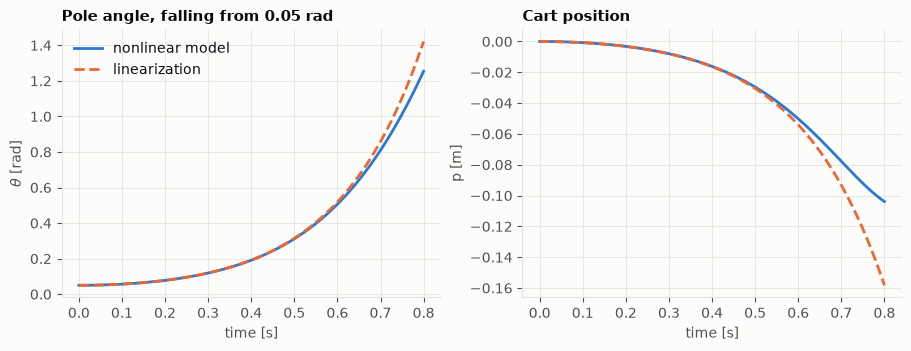

theta differs by 1% from t = 0.50 s, where it is 0.32 rad
theta at 0.8 s: nonlinear 1.254 rad, linear 1.421 rad


In [4]:
TILT, T_FALL = 0.05, 0.8  # rad, s
x_tilt = np.array([0.0, TILT, 0.0, 0.0])
t_fall = np.linspace(0.0, T_FALL, 201)
fall = solve_ivp(lambda t, x: f_np(x, U_EQ), (0.0, T_FALL), x_tilt, t_eval=t_fall, rtol=1e-10, atol=1e-12).y
fall_linear = np.stack([expm(a * t) @ x_tilt for t in t_fall], axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4))
ax1.plot(t_fall, fall[1], color=plotstyle.BLUE, label="nonlinear model")
ax1.plot(t_fall, fall_linear[1], "--", color=plotstyle.ORANGE, label="linearization")
ax1.set_xlabel("time [s]")
ax1.set_ylabel(r"$\theta$ [rad]")
ax1.set_title("Pole angle, falling from 0.05 rad")
ax1.legend()
ax2.plot(t_fall, fall[0], color=plotstyle.BLUE)
ax2.plot(t_fall, fall_linear[0], "--", color=plotstyle.ORANGE)
ax2.set_xlabel("time [s]")
ax2.set_ylabel("p [m]")
ax2.set_title("Cart position")
plt.show()
apart = np.argmax(np.abs(fall[1] - fall_linear[1]) > 0.01 * np.abs(fall[1]))
print(f"theta differs by 1% from t = {t_fall[apart]:.2f} s, where it is {fall[1, apart]:.2f} rad")
print(f"theta at {T_FALL} s: nonlinear {fall[1, -1]:.3f} rad, linear {fall_linear[1, -1]:.3f} rad")

The Jacobians match the closed form exactly, and away from the equilibrium they match central
differences to $10^{-9}$, the accuracy of the differences themselves. The unstable pole is
5.05 s$^{-1}$: a tilt grows by $e$ every 0.2 s. The linear and nonlinear falls agree until the
angle is about 0.3 rad (at 0.5 s they differ by 1%); by 0.8 s the linear model has the pole at
1.42 rad where the nonlinear one has it at 1.25, and the cart's motion has turned round, which
the linear model cannot do.

## Zero-order hold

With the input held at $u_k$ over a sampling interval $\Delta t$, the linear system has the exact
solution

$$
x_{k+1} = A_d x_k + B_d u_k, \qquad A_d = e^{A \Delta t}, \qquad B_d = \int_0^{\Delta t} e^{A s}\, ds\; B,
$$

and both matrices are blocks of one exponential,
$\exp\left(\begin{bmatrix} A & B \\ 0 & 0 \end{bmatrix} \Delta t\right) = \begin{bmatrix} A_d & B_d \\ 0 & I \end{bmatrix}$,
which is how `si.zoh(A, B, dt)` computes them. The check is `solve_ivp` of the linear system with
the input held, and the double integrator, whose discretization every textbook gives:
$A_d = \begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix}$, $B_d = \begin{bmatrix} \Delta t^2 / 2 \\ \Delta t \end{bmatrix}$.

In [5]:
DT = 0.1
X0 = np.array([0.1, -0.05, 0.2, 0.3])
U0, U1 = np.array([1.5]), np.array([-2.0])


def linear_flow(x0, u_of_t, dt):
  """The linear system over one interval, the reference for ZOH and FOH."""
  return solve_ivp(lambda t, x: a @ x + b @ u_of_t(t), (0.0, dt), x0, method="DOP853", rtol=1e-13, atol=1e-14).y[:, -1]


ad, bd = si.zoh(a, b, DT)
zoh_vs_ode = np.abs(ad @ X0 + bd @ U0 - linear_flow(X0, lambda t: U0, DT)).max()
di_ad, di_bd = si.zoh(np.array([[0.0, 1.0], [0.0, 0.0]]), np.array([[0.0], [1.0]]), DT)
zoh_double_integrator = max(np.abs(di_ad - [[1.0, DT], [0.0, 1.0]]).max(), np.abs(di_bd - [[DT**2 / 2], [DT]]).max())
print(f"cart-pole, dt = {DT}: |ZOH - solve_ivp| = {zoh_vs_ode:.1e}")
print(f"double integrator: |ZOH - textbook| = {zoh_double_integrator:.1e}")

cart-pole, dt = 0.1: |ZOH - solve_ivp| = 3.1e-15
double integrator: |ZOH - textbook| = 0.0e+00


Both agree to rounding. The double integrator's matrix is nilpotent, its exponential series
stops after two terms, and `expm` returns the textbook matrices to the last bit.

## First-order hold

When the input ramps linearly from $u_k$ to $u_{k+1}$ over the interval,
$u(t) = u_k + (u_{k+1} - u_k)\, t / \Delta t$, the exact update needs both samples:

$$
x_{k+1} = A_d x_k + B_0 u_k + B_1 u_{k+1},
$$

read off $\exp\left(\begin{bmatrix} A & B & 0 \\ 0 & 0 & I / \Delta t \\ 0 & 0 & 0 \end{bmatrix} \Delta t\right)$ by
`si.foh(A, B, dt)`. ZOH, holding $u_k$, misses the ramp's contribution,
$\int_0^{\Delta t} e^{A (\Delta t - s)} B\, (u_{k+1} - u_k)\, s / \Delta t\; ds \approx B\, (u_{k+1} - u_k)\, \Delta t / 2$,
which for a given step in the input is first order in $\Delta t$: halving the interval halves it.

In [6]:
ramp = []
for dt in (DT, DT / 2):
  exact = linear_flow(X0, lambda t, dt=dt: U0 + (U1 - U0) * t / dt, dt)
  fad, b0, b1 = si.foh(a, b, dt)
  zad, zbd = si.zoh(a, b, dt)
  ramp.append((dt, np.abs(fad @ X0 + b0 @ U0 + b1 @ U1 - exact).max(), np.abs(zad @ X0 + zbd @ U0 - exact).max()))
zoh_ramp_ratio = ramp[0][2] / ramp[1][2]
print(f"one interval, u from {U0[0]} to {U1[0]}:")
print(f"  {'dt':>6}  {'FOH error':>9}  {'ZOH error':>9}")
for dt, foh_error, zoh_error in ramp:
  print(f"  {dt:6.3f}  {foh_error:9.1e}  {zoh_error:9.1e}")
print(f"ZOH's error ratio when dt halves: {zoh_ramp_ratio:.2f}")

one interval, u from 1.5 to -2.0:
      dt  FOH error  ZOH error
   0.100    3.7e-16    3.6e-01
   0.050    1.9e-16    1.8e-01
ZOH's error ratio when dt halves: 2.03


Over many samples the difference accumulates. A sinusoidal force sampled every $\Delta t$ and
interpolated linearly between samples drives the linearized cart-pole from rest; `solve_ivp`
integrates the same piecewise-linear input interval by interval, and the two discrete models step
from sample to sample.

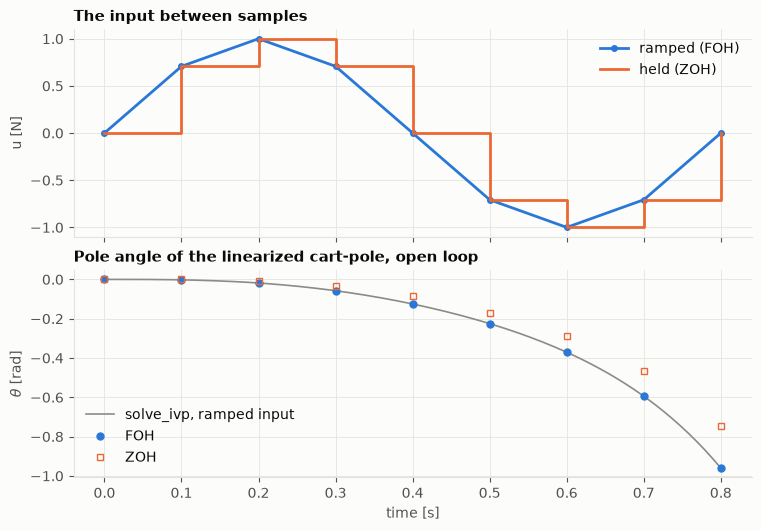

over 8 samples: |FOH - solve_ivp| = 2.1e-13, |ZOH - solve_ivp| = 1.13
theta at 0.8 s: solve_ivp -0.960 rad, FOH -0.960 rad, ZOH -0.746 rad


In [7]:
SAMPLES, U_AMP, U_PERIOD = 8, 1.0, 0.8  # samples, N, s
t_k = DT * np.arange(SAMPLES + 1)
u_k = U_AMP * np.sin(2 * np.pi * t_k / U_PERIOD)
fad, b0, b1 = si.foh(a, b, DT)
x_ref, x_zoh, x_foh = [np.zeros(4)], [np.zeros(4)], [np.zeros(4)]
t_dense, theta_dense = [], []
for k in range(SAMPLES):
  slope = (u_k[k + 1] - u_k[k]) / DT
  sol = solve_ivp(
    lambda t, x, k=k, slope=slope: a @ x + b[:, 0] * (u_k[k] + slope * t),
    (0.0, DT),
    x_ref[-1],
    method="DOP853",
    rtol=1e-13,
    atol=1e-14,
    dense_output=True,
  )
  t_dense.append(t_k[k] + np.linspace(0.0, DT, 20))
  theta_dense.append(sol.sol(np.linspace(0.0, DT, 20))[1])
  x_ref.append(sol.y[:, -1])
  x_zoh.append(ad @ x_zoh[-1] + bd @ u_k[k : k + 1])
  x_foh.append(fad @ x_foh[-1] + b0 @ u_k[k : k + 1] + b1 @ u_k[k + 1 : k + 2])
x_ref, x_zoh, x_foh = np.array(x_ref), np.array(x_zoh), np.array(x_foh)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.5, 5.2), sharex=True)
ax1.plot(t_k, u_k, "o-", color=plotstyle.BLUE, ms=4, label="ramped (FOH)")
ax1.step(t_k, u_k, where="post", color=plotstyle.ORANGE, label="held (ZOH)")
ax1.set_ylabel("u [N]")
ax1.set_title("The input between samples")
ax1.legend()
ax2.plot(np.concatenate(t_dense), np.concatenate(theta_dense), color=plotstyle.NEUTRAL, lw=1.2, label="solve_ivp, ramped input")
ax2.plot(t_k, x_foh[:, 1], "o", color=plotstyle.BLUE, label="FOH")
ax2.plot(t_k, x_zoh[:, 1], "s", color=plotstyle.ORANGE, mfc="none", label="ZOH")
ax2.set_xlabel("time [s]")
ax2.set_ylabel(r"$\theta$ [rad]")
ax2.set_title("Pole angle of the linearized cart-pole, open loop")
ax2.legend()
plt.show()
print(f"over {SAMPLES} samples: |FOH - solve_ivp| = {np.abs(x_foh - x_ref).max():.1e}, |ZOH - solve_ivp| = {np.abs(x_zoh - x_ref).max():.2f}")
print(f"theta at {t_k[-1]:.1f} s: solve_ivp {x_ref[-1, 1]:.3f} rad, FOH {x_foh[-1, 1]:.3f} rad, ZOH {x_zoh[-1, 1]:.3f} rad")

FOH is exact for the ramp: $4 \times 10^{-16}$ over one interval, $2 \times 10^{-13}$ over eight,
where the unstable pole amplifies rounding. ZOH misses by 0.36 rad/s in $\dot\theta$ over one
0.1 s interval in which the input changes by 3.5 N, and by half that over 0.05 s (ratio 2.03), as
$B (u_{k+1} - u_k) \Delta t / 2$ predicts.
Along the sinusoid its held input is on average half a sample late, the unstable pole amplifies
the lag, and at 0.8 s it puts the pole at $-0.75$ rad where the ramped input takes it to $-0.96$.

## Linearize then discretize, or discretize then linearize

`si.rk4(cartpole, dt=None)` is the map $F(x, u, \Delta t)$ of one classical Runge-Kutta step, with
the interval as an input. `si.linearize` of the map returns one Jacobian per input: $A_d$ in $x$,
$B_d$ in $u$, and a third in $\Delta t$, which is zero at an equilibrium since $f(x_{eq}, u_{eq}) = 0$.

At an equilibrium every stage of the step evaluates $f$ at $(x_{eq}, u_{eq})$, so the chain rule
gives the RK4 step of the linear model: $A_d^{RK4} = \sum_{j=0}^{4} (A \Delta t)^j / j!$, the
exponential's Taylor series cut after the fourth power. Linearize-then-discretize gives the whole
series, so

$$
A_d^{ZOH} - A_d^{RK4} = \frac{(A \Delta t)^5}{5!} + O(\Delta t^6),
$$

RK4's local error: halving $\Delta t$ divides the difference by about $2^5 = 32$. With $\Delta t$
an input, one generated map and its Jacobians serve the whole sweep.

In [8]:
SWEEP = (0.1, 0.05, 0.025, 0.0125, 0.00625)
cartpole_rk4 = si.rk4(cartpole, dt=None)
print(f"{cartpole_rk4.name}{cartpole_rk4.input_names} -> {cartpole_rk4.output_names}")
orders = []
for dt in SWEEP:
  ad_rk, bd_rk, ad_dt = si.linearize(cartpole_rk4, X_EQ, U_EQ, np.array(dt))
  ad_ex, bd_ex = si.zoh(a, b, dt)
  orders.append((dt, np.abs(ad_rk - ad_ex).max(), np.abs(bd_rk - bd_ex).max(), np.abs(ad_dt).max()))
order_ratios = [orders[i][1] / orders[i + 1][1] for i in range(len(orders) - 1)]
print(f"largest entry of Ad at dt = {SWEEP[0]}: {np.abs(si.zoh(a, b, SWEEP[0])[0]).max():.2f}")
print(f"  {'dt':>7}  {'|dAd|':>8}  {'|dBd|':>8}  {'ratio':>6}  {'d/d dt':>6}")
for i, (dt, da, db, ddt) in enumerate(orders):
  ratio = f"{order_ratios[i - 1]:6.1f}" if i else ""
  print(f"  {dt:7.5f}  {da:8.2e}  {db:8.2e}  {ratio:>6}  {ddt:6.1e}")

lindisc_cartpole_rk4('x', 'u', 'dt') -> ('xnext',)


largest entry of Ad at dt = 0.1: 2.66
       dt     |dAd|     |dBd|   ratio  d/d dt
  0.10000  1.39e-03  1.09e-04          0.0e+00
  0.05000  4.33e-05  3.39e-06    32.1  0.0e+00
  0.02500  1.35e-06  1.06e-07    32.0  0.0e+00
  0.01250  4.22e-08  3.31e-09    32.0  0.0e+00
  0.00625  1.32e-09  1.03e-10    32.0  0.0e+00


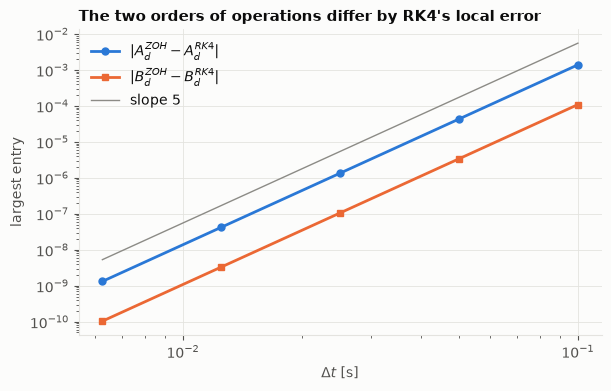

In [9]:
dts, da, db = (np.array([row[i] for row in orders]) for i in range(3))
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.loglog(dts, da, "o-", color=plotstyle.BLUE, label=r"$|A_d^{ZOH} - A_d^{RK4}|$")
ax.loglog(dts, db, "s-", color=plotstyle.ORANGE, label=r"$|B_d^{ZOH} - B_d^{RK4}|$")
ax.loglog(dts, 4 * da[0] * (dts / dts[0]) ** 5, color=plotstyle.NEUTRAL, lw=1, label=r"slope 5")
ax.set_xlabel(r"$\Delta t$ [s]")
ax.set_ylabel("largest entry")
ax.set_title("The two orders of operations differ by RK4's local error")
ax.legend()
plt.show()

The ratio is 32.0 from $\Delta t = 0.05$ down, the fifth power; at $\Delta t = 0.1$, where
$\lambda \Delta t = 0.5$, the next term of the series adds a little (32.1). The difference in
$B_d$ is about 13 times smaller and falls at the same rate, and the Jacobian in $\Delta t$ is zero,
as it must be at an equilibrium. At $\Delta t = 0.1$ the two models differ by $1.4 \times 10^{-3}$
in entries up to 2.66, so for this model and sampling time the order of operations changes the
linear model in the third digit.

## Checks

The numbers above, held to tolerances with a margin of about ten over what was measured.

In [10]:
checks = 0
assert a_vs_closed_form < 1e-12 and b_vs_closed_form < 1e-12
checks += 1
assert a_off_vs_differences < 2e-8 and b_off_vs_differences < 2e-8
checks += 1
assert zoh_vs_ode < 1e-12 and zoh_double_integrator < 1e-14
checks += 1
for _, foh_error, zoh_error in ramp:
  assert foh_error < 1e-12 and zoh_error > 0.1  # a first-order hold is exact for a ramp, a zero-order one is not
  checks += 1
assert abs(zoh_ramp_ratio - 2) < 0.15
checks += 1
assert all(30 < ratio < 34 for ratio in order_ratios)  # RK4's local error, O(dt^5)
checks += 1
print(f"{checks} checks passed")

7 checks passed


## The generated C

The RK4 map is one C function, `lindisc_cartpole_rk4`: the model is generated once as a kernel,
`lindisc_cartpole_raw`, and each of the four stages calls it. The step's weights fold as one would
write them by hand, $x + \frac{\Delta t}{6}(k_1 + 2 k_2 + 2 k_3 + k_4)$.

In [11]:
module = write_module(cartpole_rk4, GENERATED)
print(
  f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.1f} kB, in {GENERATED.relative_to(Path.cwd().parent.parent)}"
)
lines = module.source.splitlines()
start = next(i for i, line in enumerate(lines) if line.startswith("int lindisc_cartpole_rk4("))
print("\n".join(lines[start : lines.index("}", start) + 1]))

lindisc_cartpole_rk4.c: 71 lines, 2.2 kB, in examples/generated/integrators/linearize_and_discretize
int lindisc_cartpole_rk4(const double** arg, double** res, int* iw, double* w, int mem) {
  (void)iw;
  (void)mem;
  if (!arg || !res) return SCALY_ERR_NULL_ABI;
  (void)w;
  if (!arg[0]) return SCALY_ERR_NULL_INPUT;
  if (!arg[1]) return SCALY_ERR_NULL_INPUT;
  if (!arg[2]) return SCALY_ERR_NULL_INPUT;
  if (!res[0]) return SCALY_ERR_NULL_RESULT;
  double s0[1];
  double s1[4];
  double s2[1];
  double s3[4];
  double s4[4];
  double s5[4];
  double s6[4];
  double s7[4];
  double s8[4];
  s0[0] = (arg[2][0] * 0.16666666666666666);
  lindisc_cartpole_raw(arg[0], arg[1], s1, NULL);
  s2[0] = (arg[2][0] * 0.5);
  for (long long i_t7 = 0; i_t7 < 4; ++i_t7) {
    s3[i_t7] = (arg[0][i_t7] + (s2[0] * s1[i_t7]));
  }
  lindisc_cartpole_raw(s3, arg[1], s4, NULL);
  for (long long i_t12 = 0; i_t12 < 4; ++i_t12) {
    s5[i_t12] = (arg[0][i_t12] + (s2[0] * s4[i_t12]));
  }
  lindisc_cartpole_raw(